# Example 07: Tensioned Cubic B-Spline Test
This notebook closely follows the `example_02` notebook. In this case, we use tensioned cubic B-splines to fit the profiles in the FreeGSNKE MAST-U synthetic data.

In [1]:
import os
from datetime import datetime

import gsfit_rs
import matplotlib.pyplot as plt
import numpy as np
import shapely
from gsfit import Gsfit
from scipy.constants import mu_0

%matplotlib inline

print(datetime.now())

2026-03-05 14:50:17.569660


# 1. FreeGSNKE synthetic equilibrium data
We start by constructing a FreeGSNKE equilibrium, including MAST-U's magnetic probes.

/home/alex.prokopyszyn/GitHub/Dev/gsfit/.venv/lib/python3.13/site-packages/freegsnke/build_machine.py:373: SyntaxWarning: invalid escape sequence '\c'
  """


Active coils --> built from pickle file.
Passive structures --> built from pickle file.
Limiter --> built from pickle file.
Wall --> built from pickle file.
Magnetic probes --> built from pickle file.
Resistance (R) and inductance (M) matrices --> built using actives (and passives if present).
Tokamak built.


/home/alex.prokopyszyn/GitHub/Dev/gsfit/.venv/lib/python3.13/site-packages/freegsnke/GSstaticsolver.py:186: SyntaxWarning: invalid escape sequence '\e'
  """Residual of the nonlinear Grad Shafranov equation written as a root problem


Forward static solve SUCCESS. Tolerance 3.10e-10 (vs. requested 1.00e-09) reached in 26/100 iterations.


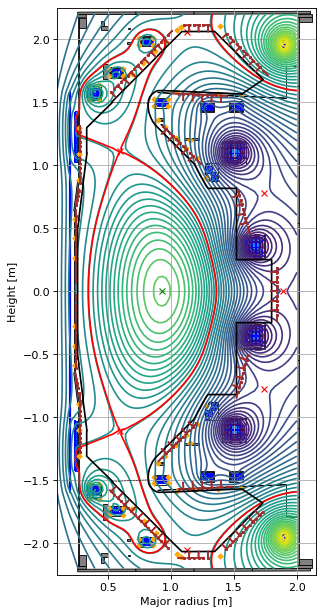

In [2]:
# build the machine
from freegsnke import build_machine

# include the paths to data files
freegsnke_tokamak = build_machine.tokamak(
    active_coils_path=os.path.expanduser("~/github/freegsnke/machine_configs/MAST-U/MAST-U_like_active_coils.pickle"),
    passive_coils_path=os.path.expanduser("~/github/freegsnke/machine_configs/MAST-U/MAST-U_like_passive_coils.pickle"),
    limiter_path=os.path.expanduser("~/github/freegsnke/machine_configs/MAST-U/MAST-U_like_limiter.pickle"),
    wall_path=os.path.expanduser("~/github/freegsnke/machine_configs/MAST-U/MAST-U_like_wall.pickle"),
    magnetic_probe_path=os.path.expanduser("~/github/freegsnke/machine_configs/MAST-U/MAST-U_like_magnetic_probes.pickle"),
)

# initialise the equilibrium
from freegsnke import equilibrium_update

freegsnke_eq = equilibrium_update.Equilibrium(
    tokamak=freegsnke_tokamak,
    Rmin=0.1,
    Rmax=2.0,
    Zmin=-2.2,
    Zmax=2.2,
    nx=65,
    ny=129,
)

# initialise the profiles
from freegsnke.jtor_update import ConstrainPaxisIp

# We use alpha_m=2.0 and alpha_n=1.0 to to get simple quadratic profiles.
profiles = ConstrainPaxisIp(
    eq=freegsnke_eq,  # equilibrium object
    paxis=8e3,  # pressure at axis [pascal]
    Ip=600.0e3,  # plasma current
    fvac=0.5,  # fvac = rB_{tor}
    alpha_m=2.0,  # profile function parameter
    alpha_n=1.0,  # profile function parameter
)

# load the nonlinear solverz
from freegsnke import GSstaticsolver

GSStaticSolver = GSstaticsolver.NKGSsolver(freegsnke_eq)

# set the coil currents
import pickle

with open(os.path.expanduser("~/github/freegsnke/examples/data/simple_diverted_currents_PaxisIp.pk"), "rb") as f:
    current_values = pickle.load(f)
for key in current_values.keys():
    freegsnke_eq.tokamak[key].current = current_values[key]

# carry out the forward solve to find the equilibrium
GSStaticSolver.solve(eq=freegsnke_eq, profiles=profiles, constrain=None, target_relative_tolerance=1e-9)

# updates the plasma_psi
freegsnke_eq._updatePlasmaPsi(freegsnke_eq.plasma_psi)

# Initialise the sensors (calculate the Greens tables)
freegsnke_tokamak.probes.initialise_setup(freegsnke_eq)

# plot the resulting equilbria
fig1, ax1 = plt.subplots(1, 1, figsize=(4, 8), dpi=80)
ax1.grid(True, which="both")
freegsnke_eq.plot(axis=ax1, show=False)
freegsnke_eq.tokamak.plot(axis=ax1, show=False)
ax1.set_xlim(0.1, 2.15)
ax1.set_ylim(-2.25, 2.25)
freegsnke_eq.tokamak.probes.plot(axis=ax1, show=False, floops=True, pickups=True, pickups_scale=0.05)
plt.tight_layout()

# 2. Equilibrium reconstruction with GSFit

## 2.1 Setup GSFit controller

In [3]:
# Setup GSFit using the settings for MAST-U.
gsfit_controller = Gsfit(
    pulseNo=0,
    run_name="test",
    settings_path="mastu_with_synthetic_data_from_freegsnke",
    write_to_mds=False,
)

# GSFit is naturally a time-dependent code
time = np.array([0.0, 1.0])
freegsnke_eqs = [freegsnke_eq, freegsnke_eq]  # we could extend this example to include time-dependent equilibria

2026-03-05 14:50:53  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "GSFIT_code_settings.json"
2026-03-05 14:50:53  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "passive_dof_regularisation.json"
2026-03-05 14:50:53  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_bp_probe.json"
2026-03-05 14:50:53  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_dialoop.json"
2026-03-05 14:50:53  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_flux_loops.json"
2026-03-05 14:50:53  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_isoflux.json"
2026-03-05 14:50:53  |  GSFIT  |  diagnostic_and_simulation_base.py:159  |  INFO  |  Loading settings from: "sensor_weights_pressure.json"
2026-03-05 14:50:53  |  GSFI

## 2.2 Setup Tensioned Cubic B Splines

### 2.2.1 Setup dummy source function to call   gsfit_rs.TensionedCubicBSpline functions we need. 

In [4]:
# Select interior knot locations in psi_n space.
# Boundary knots at psi_n = 0 and psi_n = 1 are automatically included and should not be specified here.
#
# The knot locations are chosen to be consistent with those used in:
# Szepesi, G. et al., "Advanced equilibrium reconstruction for JET with EFIT++",
# 47th EPS Conference on Plasma Physics, EPS 2021,
# 21–25 June 2021, pp. 633–636.

interior_knots = np.array([0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.98])

# Number of degrees of freedom for the spline coefficients.
# For a cubic spline representation, the DOF equals the number of interior knots plus 4.
n_dof = len(interior_knots) + 4

# We set the tension over each interval to 2.0, somewhat arbitrarily.
# The tension is a parameter that controls how "stiff" each interval between knots i and i+1 is, with higher values leading to a stiffer spline.
interval_tensions = np.ones(len(interior_knots) + 1, dtype=np.float64) * 2.0


# We set up a p_prime_source_function dummy function that we use to call functions we need from GSFit
regularisations_dummy = np.zeros((1, n_dof), dtype=np.float64)
p_prime_source_function_dummy = gsfit_rs.TensionedCubicBSpline(regularisations_dummy, interior_knots, interval_tensions)

### 2.2.2 Visualise B-Splines and check formula for the derivative (Optional)

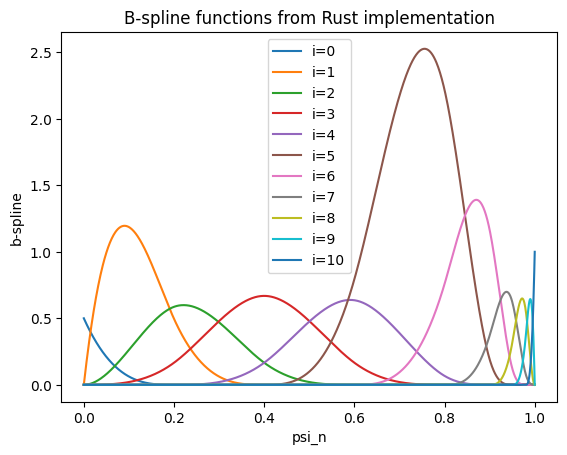

In [5]:
# We will need these arrays
sigma1_array = p_prime_source_function_dummy.get_array1("sigma1_array")
sigma2_array = p_prime_source_function_dummy.get_array1("sigma2_array")
gamma2_array = p_prime_source_function_dummy.get_array1("gamma2_array")

# We are going to visiualise the degrees of freedom
p_prime_dummy_dof_array = np.ones(n_dof, dtype=np.float64)
# To make it intersting we will set some of coefficents to values other than 1.0
p_prime_dummy_dof_array[0] = 0.5
p_prime_dummy_dof_array[1] = 2.0
p_prime_dummy_dof_array[5] = 4.0
p_prime_dummy_dof_array[6] = 2.0

n_psi_n = 1001
psi_n_array = np.linspace(0, 1, n_psi_n)
b_spline_array = np.zeros((n_dof, n_psi_n))
for i in range(n_dof):
    for j in range(n_psi_n):
        b_spline_array[i, j] = p_prime_dummy_dof_array[i] * p_prime_source_function_dummy.source_function_value_single_dof_python(psi_n_array[j], i)
        
fig, ax = plt.subplots()
for i in range(n_dof):
    ax.plot(psi_n_array, b_spline_array[i, :], label=f"i={i}")
ax.set_xlabel("psi_n")
ax.set_ylabel("b-spline")
ax.set_title("B-spline functions from Rust implementation")
ax.legend()

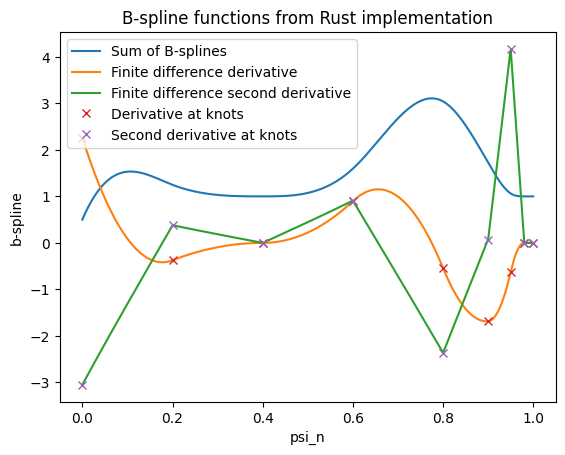

In [6]:
# Verify the formulas for the first and second derivatives derived in the following LaTeX document:
# https://www.overleaf.com/read/vbydpqkjtmds#910342
#
# The derivations make extensive use of results from:
# P. E. Koch and T. Lyche, "Interpolation with Exponential B-Splines in Tension",
# in *Geometric Modelling*, pp. 173–190.

knots = np.concatenate(([0], interior_knots, [1]))
derivative_at_knots_array = np.zeros(len(knots), dtype=np.float64)
second_derivative_at_knots_array = np.zeros(len(knots), dtype=np.float64)
for knot_i, knot in enumerate(knots):
    j = knot_i + 3
    c_jm3 = p_prime_dummy_dof_array[j-3]
    c_jm2 = p_prime_dummy_dof_array[j-2]
    c_jm1 = p_prime_dummy_dof_array[j-1]
    derivative_at_knot = -c_jm3 * gamma2_array[j] / (sigma2_array[j-2] * sigma1_array[j-1]) \
                       +  c_jm2 * (gamma2_array[j] / (sigma2_array[j-2] * sigma1_array[j-1]) - gamma2_array[j-1] / (sigma2_array[j-1] * sigma1_array[j-1])) \
                       +  c_jm1 * gamma2_array[j-1] / (sigma2_array[j-1] * sigma1_array[j-1])
    derivative_at_knots_array[knot_i] = derivative_at_knot
    second_derivative_at_knot = c_jm3 / (sigma2_array[j-2] * sigma1_array[j-1]) \
                              - c_jm2 * (1.0 / sigma2_array[j-2] +  1.0 / sigma2_array[j-1]) / sigma1_array[j-1] \
                              + c_jm1 / (sigma2_array[j-1] * sigma1_array[j-1])
    second_derivative_at_knots_array[knot_i] = second_derivative_at_knot
    
    b_spline_sum = np.sum(b_spline_array, axis=0)
b_spline_sum_dx = np.zeros_like(b_spline_sum)
b_spline_sum_dx = (b_spline_sum[2:] - b_spline_sum[:-2]) / (psi_n_array[2] - psi_n_array[0])
b_spline_sum_dx2 = (b_spline_sum[:-2] - 2 * b_spline_sum[1:-1] + b_spline_sum[2:]) / ((psi_n_array[1] - psi_n_array[0]) ** 2)
fig, ax = plt.subplots()
ax.plot(psi_n_array, np.sum(b_spline_array, axis=0), label="Sum of B-splines")
ax.plot(psi_n_array[1:-1], b_spline_sum_dx / 10, label="Finite difference derivative")
ax.plot(psi_n_array[1:-1], b_spline_sum_dx2 / 100, label="Finite difference second derivative")
ax.plot(knots, derivative_at_knots_array / 10, "x", label="Derivative at knots")
ax.plot(knots, second_derivative_at_knots_array / 100, "x", label="Second derivative at knots")

ax.set_xlabel("psi_n")
ax.set_ylabel("b-spline")
ax.set_title("B-spline functions from Rust implementation")
ax.legend()

### 2.2.3 Calculate regularisations

In [7]:
# Regularisation strategy:
#
# 1. Impose a weak regularisation (weight = 1e-7) that sets the second derivative of p_prime
#    with respect to psi_n to zero at all knot locations. This promotes smooth curvature.
#
# 2. Impose a strong regularisation to enforce zero first derivative of p_prime at psi_n = 0.
#
# 3. Impose a very strong regularisation to enforce p_prime = 0 at psi_n = 1.
#
# The resulting regularisation matrix should therefore have (len(knots) + 2) rows and n_dof columns:
#   - Row 0: Enforces dp_prime/dpsi_n = 0 at psi_n = 0.
#   - Rows 1 to len(knots): Enforce d²p_prime/dpsi_n² = 0 at each knot location.
#   - Final row: Enforces p_prime = 0 at psi_n = 1.

p_prime_regularisations_array = np.zeros((len(knots) + 2, n_dof), dtype=np.float64)

# Impose dp_prime/dpsi_n = 0 at psi_n = 0
# See final line of this LaTeX document for the formula for the first derivative at the boundary:
# https://www.overleaf.com/read/vbydpqkjtmds#910342
p_prime_regularisations_array[0, 0] = 1e10
p_prime_regularisations_array[0, 1] = -1e10

# Impose d²p_prime/dpsi_n² = 0 at each knot location
for i in range(len(knots)):
    j = i + 3
    p_prime_regularisations_array[i+1, j-3] = 1.0 / (sigma2_array[j-2] * sigma1_array[j-1])
    p_prime_regularisations_array[i+1, j-2] = -(1.0 / sigma2_array[j-2] + 1.0 / sigma2_array[j-1]) / sigma1_array[j-1]
    p_prime_regularisations_array[i+1, j-1] = 1.0 / (sigma2_array[j-1] * sigma1_array[j-1])
    p_prime_regularisations_array[i+1, :] *= 1e-6
    
# Impose p_prime = 0 at psi_n = 1
p_prime_regularisations_array[-1, -1] = 1e10

# Since we know ffprime is quadratic, we are going to help GSFit by including a regularisation
# which enforces that the first and second degree of freedoms are equal
ff_prime_regulrisations_array = np.zeros((1, 2), dtype=np.float64)
ff_prime_regulrisations_array[0, 0] = 1e5
ff_prime_regulrisations_array[0, 1] = -1e5

p_prime_regularisations_array

array([[ 1.00000000e+10, -1.00000000e+10,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.52805015e-04, -2.28601383e-04,  7.57963687e-05,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  3.78981843e-05, -6.32306321e-05,  2.53324478e-05,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  2.53324478e-05, -5.06648956e-05,  2.53324478e-05,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  2.53324478e-05, -5.56513359e-05,  3.03188880e-05,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e

## 2.2 Setup GSFit controller source functions

In [8]:
gsfit_controller.settings["source_function_p_prime.json"]["method"] = "tensioned_cubic_b_spline"
gsfit_controller.settings["source_function_p_prime.json"]["tensioned_cubic_b_spline"]["regularizations"] = p_prime_regularisations_array.tolist()
gsfit_controller.settings["source_function_p_prime.json"]["tensioned_cubic_b_spline"]["interior_knots"] = interior_knots.tolist()
gsfit_controller.settings["source_function_p_prime.json"]["tensioned_cubic_b_spline"]["interval_tensions"] = interval_tensions.tolist()

gsfit_controller.settings["source_function_ff_prime.json"]["method"] = "efit_polynomial"
gsfit_controller.settings["source_function_ff_prime.json"]["efit_polynomial"]["n_dof"] = 2
gsfit_controller.settings["source_function_ff_prime.json"]["efit_polynomial"]["regularizations"] = ff_prime_regulrisations_array.tolist()


## 2.3 Run GSFit

In [9]:
# Solve the equilibrium reconstruction using the FreeGSNKE equilibrium object as measurements
gsfit_controller.run(
    time=time,
    freegsnke_eqs=freegsnke_eqs,
)

# We can now access the results from the GSFit reconstruction
plasma = gsfit_controller.plasma
flux_loops = gsfit_controller.flux_loops
bp_probes = gsfit_controller.bp_probes

2026-03-05 14:50:54  |  GSFIT  |  gsfit.py:91                            |  INFO  |  Running Gsfit, for pulseNo=0
2026-03-05 14:50:54  |  GSFIT  |  gsfit.py:283                           |  INFO  |  `coils`  initialised;  0.57ms
2026-03-05 14:50:54  |  GSFIT  |  gsfit.py:288                           |  INFO  |  `bp_probes` initialised;  10.08ms
2026-03-05 14:50:54  |  GSFIT  |  gsfit.py:293                           |  INFO  |  `flux_loops` initialised;  3.59ms
2026-03-05 14:50:54  |  GSFIT  |  gsfit.py:298                           |  INFO  |  `rogowski_coils` initialised;  0.07ms
2026-03-05 14:50:54  |  GSFIT  |  gsfit.py:303                           |  INFO  |  `passives` initialised;  0.01ms
2026-03-05 14:50:54  |  GSFIT  |  gsfit.py:308                           |  INFO  |  `plasma` initialised;  183.52ms
2026-03-05 14:50:54  |  GSFIT  |  gsfit.py:314                           |  INFO  |  `isoflux` initialised;  0.02ms
2026-03-05 14:50:54  |  GSFIT  |  gsfit.py:319              

# 3 Comparison between FreeGSNKE and GSFit equilibrium reconstruction (magnetic only)

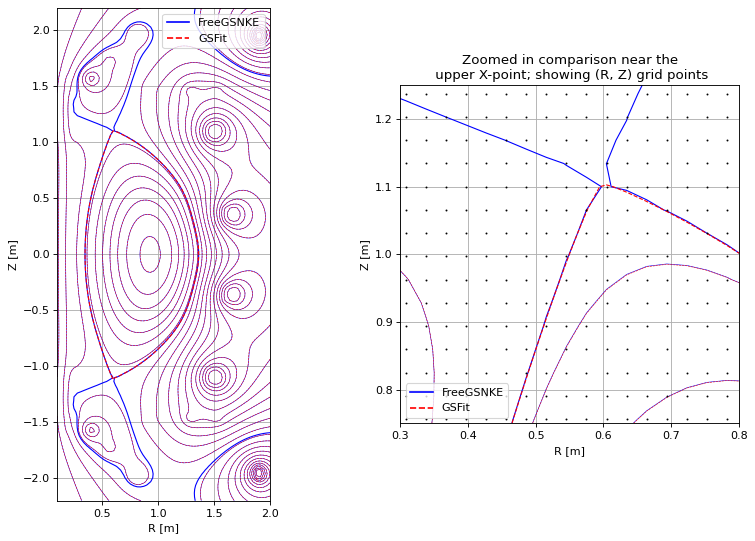

In [10]:
def plot_2d_equilibrium(freegsnke_eq, gsfit_controller):
    # Get results out of GSFit
    plasma = gsfit_controller.plasma
    i_time = 0
    gsfit_r = plasma.get_array1(["grid", "r"])
    gsfit_z = plasma.get_array1(["grid", "z"])
    gsfit_psi = plasma.get_array3(["two_d", "psi"])[i_time, :, :]
    gsfit_rbnd = plasma.get_array2(["p_boundary", "rbnd"])[i_time, :]
    gsfit_zbnd = plasma.get_array2(["p_boundary", "zbnd"])[i_time, :]
    gsfit_nbnd = plasma.get_vec_usize(["p_boundary", "nbnd"])[i_time]

    # Get results out of FreeGSNKE
    freegsnke_r = freegsnke_eq.R
    freegsnke_z = freegsnke_eq.Z
    freegsnke_psi = freegsnke_eq.psi() * (2.0 * np.pi)  # convert from "weber/(2*pi)" to "weber"
    freegsnke_psi_b = freegsnke_eq.psi_bndry * (2.0 * np.pi)

    # We will plot the same psi values for both FreeGSNKE and GSFit
    psi_range = np.linspace(np.min(freegsnke_psi), np.max(freegsnke_psi), 25)

    fig, ax = plt.subplots(1, 2, figsize=(12, 8), dpi=80)
    for i_axis in range(2):
        ax[i_axis].grid(True, which="both")
        ax[i_axis].set_aspect("equal")
        ax[i_axis].contour(
            freegsnke_r,
            freegsnke_z,
            freegsnke_psi,
            levels=psi_range,
            colors="blue",
            linewidths=0.5,
            linestyles="solid",
        )
        ax[i_axis].contour(
            freegsnke_r,
            freegsnke_z,
            freegsnke_psi,
            levels=[freegsnke_psi_b],
            colors="blue",
            linewidths=1.0,
            linestyles="solid",
        )
        ax[i_axis].contour(
            gsfit_r,
            gsfit_z,
            gsfit_psi,
            levels=psi_range,
            colors="red",
            linewidths=0.5,
            linestyles="dashed",
        )
        ax[i_axis].plot(
            gsfit_rbnd[0:gsfit_nbnd],
            gsfit_zbnd[0:gsfit_nbnd],
            color="red",
            linewidth=1.0,
            linestyle="dashed",
        )
        ax[i_axis].set_xlabel("R [m]")
        ax[i_axis].set_ylabel("Z [m]")
        ax[i_axis].plot([], [], label="FreeGSNKE", color="blue")
        ax[i_axis].plot([], [], label="GSFit", linestyle="dashed", color="red")
        ax[i_axis].legend()

    ax[1].set_xlim(0.3, 0.8)
    ax[1].set_ylim(0.75, 1.25)
    [r_mesh, z_mesh] = np.meshgrid(freegsnke_eq.R_1D, freegsnke_eq.Z_1D)
    ax[1].plot(r_mesh.flatten(), z_mesh.flatten(), "o", color="black", markersize=0.75)
    ax[1].set_title("Zoomed in comparison near the\n upper X-point; showing (R, Z) grid points")


plot_2d_equilibrium(freegsnke_eq, gsfit_controller)

2.2 Plotting profiles

In [11]:
ff_prime_gsfit = plasma.get_array2(["profiles", "ff_prime"])[0]
p_prime_gsfit = plasma.get_array2(["profiles", "p_prime"])[0]
pressure_gsfit = plasma.get_array2(["profiles", "p"])[0]
psi_n_gsfit = plasma.get_array1(["profiles", "psi_n"])
plasma_current_gsfit = plasma.get_array1(["global", "ip"])[0]

p_prime_freegsnke = freegsnke_eq.pprime(psi_n_gsfit)
ff_prime_freegsnke = freegsnke_eq.ffprime(psi_n_gsfit)
pressure_freegsnke = freegsnke_eq.pressure(psi_n_gsfit)

print(f"Plasma current from GSFit: {plasma_current_gsfit:.2e} A")
print(f"Delta z GSFit: {plasma.get_array1(['global', 'delta_z'])[0]:.2e} A")

Plasma current from GSFit: 6.00e+05 A
Delta z GSFit: -2.20e-05 A


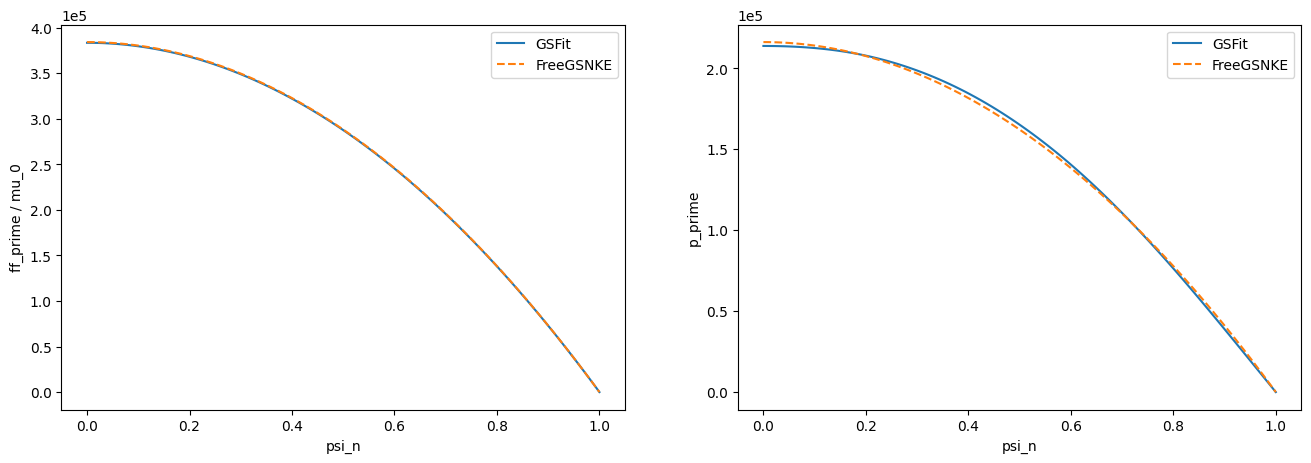

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].plot(psi_n_gsfit, ff_prime_gsfit / mu_0 * (2 * np.pi), label="GSFit")
ax[0].plot(psi_n_gsfit, ff_prime_freegsnke / mu_0, label="FreeGSNKE", linestyle="dashed")
# ax[0].plot(psi_n_gsfit[1:-1], (ff_prime_gsfit[2:] - ff_prime_gsfit[:-2]) / (psi_n_gsfit[2:] - psi_n_gsfit[:-2]) / mu_0, label="Finite difference derivative of ff_prime_gsfit", linestyle="dotted")
# ax[0].plot(psi_n_gsfit[1:-1], (ff_prime_freegsnke[2:] - ff_prime_freegsnke[:-2]) / (psi_n_gsfit[2:] - psi_n_gsfit[:-2]) / mu_0, label="Finite difference derivative of ff_prime_freegsnke", linestyle="dotted")
ax[1].plot(psi_n_gsfit, p_prime_gsfit * (2 * np.pi), label="GSFit")
ax[1].plot(psi_n_gsfit, p_prime_freegsnke, label="FreeGSNKE", linestyle="dashed")
# ax[1].plot(psi_n_gsfit[1:-1], (p_prime_gsfit[2:] - p_prime_gsfit[:-2]) / (psi_n_gsfit[2:] - psi_n_gsfit[:-2]) * (2 * np.pi), label="Finite difference derivative of p_prime_gsfit", linestyle="dotted")
# ylim0 = ax[0].get_ylim()
# ax[1].set_ylim(ylim0)
# ax[1].plot(psi_n_gsfit[1:-1], (p_prime_freegsnke[2:] - p_prime_freegsnke[:-2]) / (psi_n_gsfit[2:] - psi_n_gsfit[:-2]), label="Finite difference derivative of p_prime_freegsnke", linestyle="dotted")
ax[0].set_xlabel("psi_n")
ax[0].set_ylabel("ff_prime / mu_0")
ax[1].set_xlabel("psi_n")
ax[1].set_ylabel("p_prime")
ax[0].legend()

ax[1].legend()
# Make y-axis scientific notation
ax[0].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax[1].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))